# Lab : Image Classification using Convolutional Neural Networks

At the end of this laboratory, you would get familiarized with

*   Creating deep networks using Keras
*   Steps necessary in training a neural network
*   Prediction and performance analysis using neural networks

---

# **In case you use a colaboratory environment**
By default, Colab notebooks run on CPU.
You can switch your notebook to run with GPU.

In order to obtain access to the GPU, you need to choose the tab Runtime and then select “Change runtime type” as shown in the following figure:

![Changing runtime](https://miro.medium.com/max/747/1*euE7nGZ0uJQcgvkpgvkoQg.png)

When a pop-up window appears select GPU. Ensure “Hardware accelerator” is set to GPU.

# **Working with a new dataset: CIFAR-10**

The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images. More information about CIFAR-10 can be found [here](https://www.cs.toronto.edu/~kriz/cifar.html).

In Keras, the CIFAR-10 dataset is also preloaded in the form of four Numpy arrays. x_train and y_train contain the training set, while x_test and y_test contain the test data. The images are encoded as Numpy arrays and their corresponding labels ranging from 0 to 9.

Your task is to:

*   Visualize the images in CIFAR-10 dataset. Create a 10 x 10 plot showing 10 random samples from each class.
*   Convert the labels to one-hot encoded form.
*   Normalize the images.




In [3]:
import torch

if torch.cuda.is_available():
    print(f"✅ GPU is available: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️  No GPU detected. For faster training, consider running this notebook on Google Colab with a GPU runtime.")
    print("On Google Colab, go to: Runtime > Change runtime type > Hardware accelerator > GPU")

✅ GPU is available: Tesla T4


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

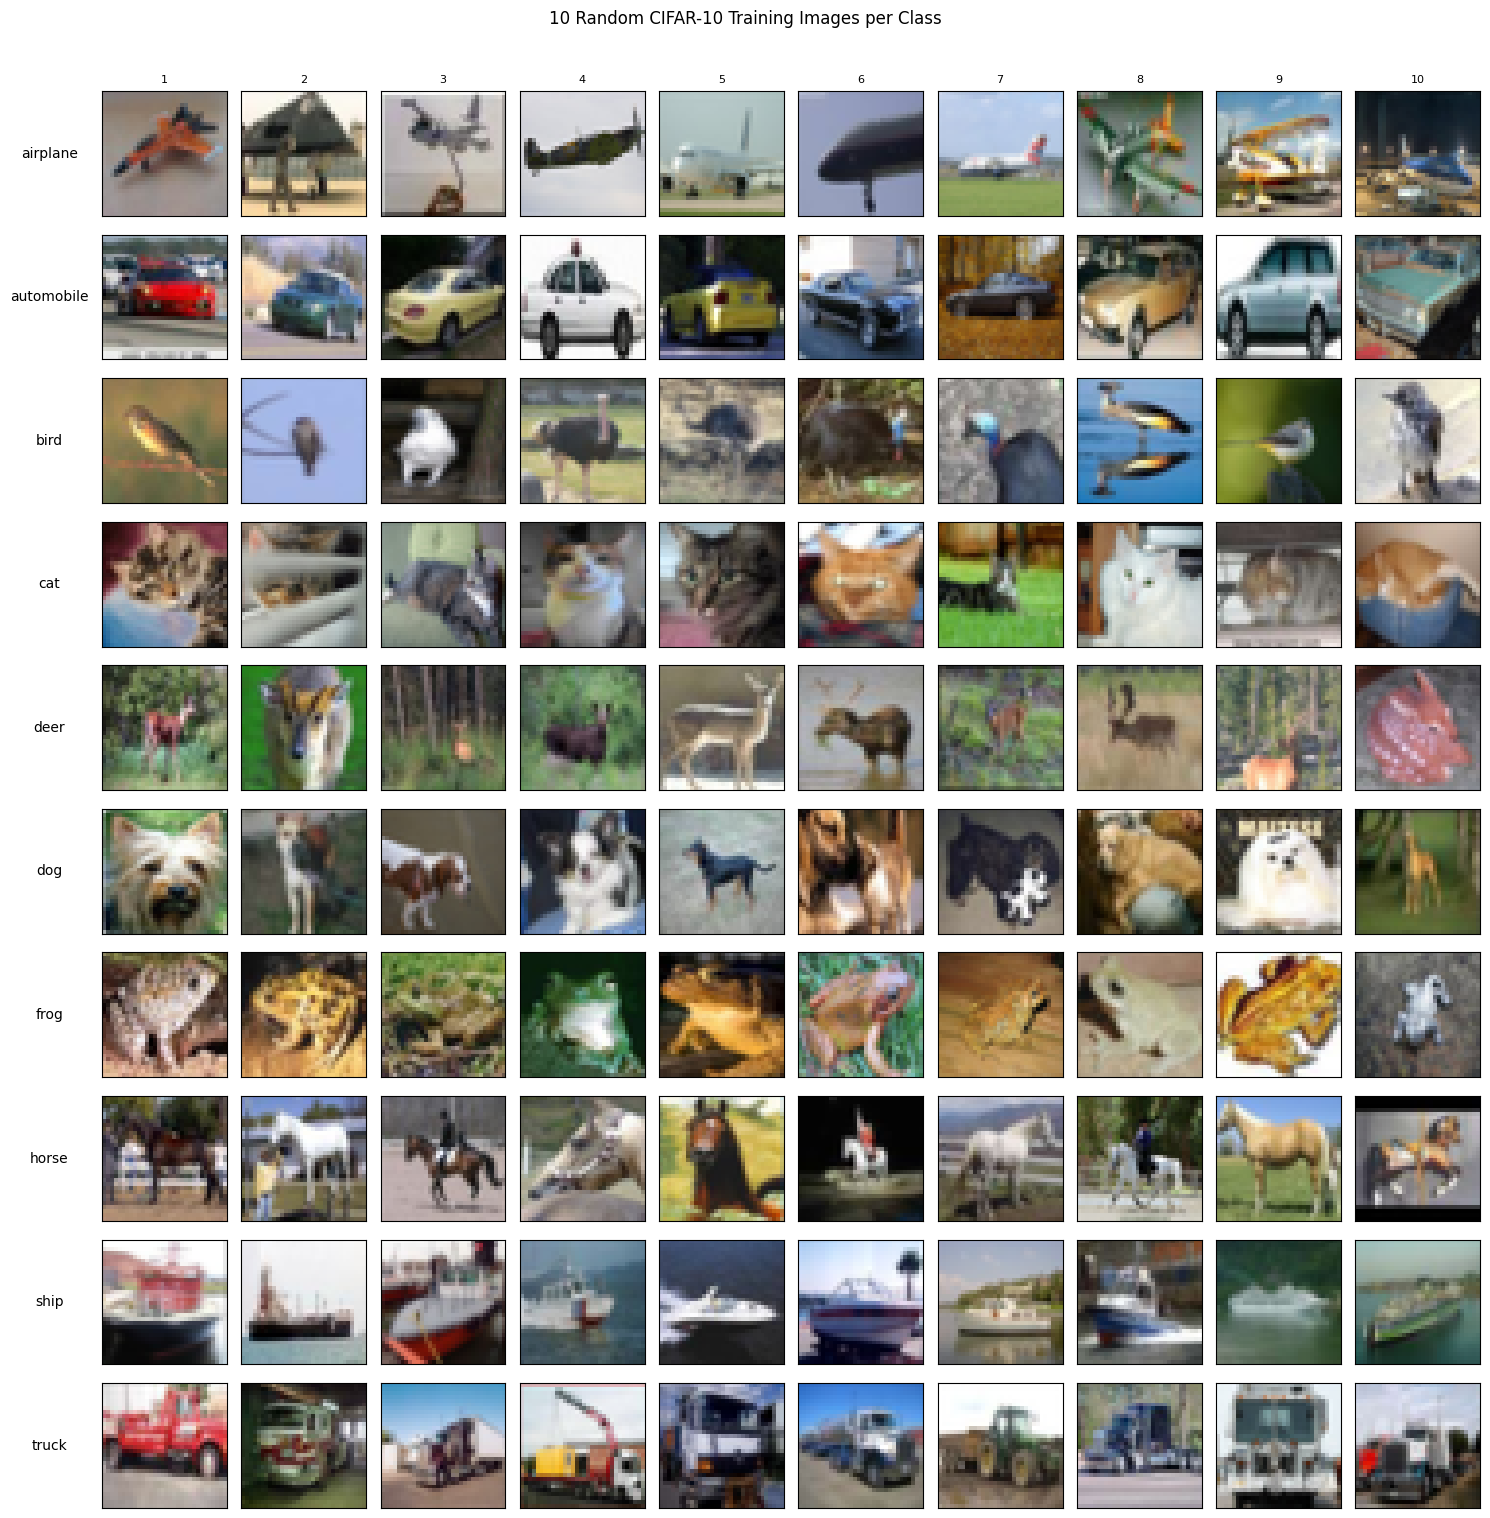

In [11]:
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]

labels = y_train.reshape(-1)
rng = np.random.default_rng()
fig, axes = plt.subplots(10, 10, figsize=(15, 15))

for class_id, class_name in enumerate(class_names):
    class_indices = np.flatnonzero(labels == class_id)
    sample_indices = rng.choice(class_indices, size=10, replace=False)

    for sample_id, image_index in enumerate(sample_indices):
        ax = axes[class_id, sample_id]
        ax.imshow(x_train[image_index])
        ax.set_xticks([])
        ax.set_yticks([])
        if class_id == 0:
            ax.set_title(f"{sample_id + 1}", fontsize=8)

    axes[class_id, 0].set_ylabel(class_name, rotation=0, labelpad=38, va="center")

fig.suptitle("10 Random CIFAR-10 Training Images per Class", y=1.01)
plt.tight_layout()
plt.show()



In [12]:
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

print(y_train_cat.shape, y_test_cat.shape)

(50000, 10) (10000, 10)


In [15]:
print(np.max(y_train_cat), np.min(y_test_cat))
print(np.max(y_test_cat), np.min(y_test_cat))

1.0 0.0
1.0 0.0


In [22]:
print(x_train.shape)
x_train_norm = x_train.astype("float32") / 255.0
x_test_norm = x_test.astype("float32") / 255.0

(50000, 32, 32, 3)


## Define the following model (same as the one in tutorial)

For the convolutional front-end, start with a single convolutional layer with a small filter size (3,3) and a modest number of filters (32) followed by a max pooling layer. 

Use the input as (32,32,3). 

The filter maps can then be flattened to provide features to the classifier. 

Use a dense layer with 100 units before the classification layer (which is also a dense layer with softmax activation).

In [5]:
from keras.backend import clear_session
clear_session()

In [30]:
# Your code here :
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential(
    [
        keras.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),  
        layers.Dense(100, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 7200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │       720,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 722,006 (2.75 MB)

 Trainable params: 722,006 (2.75 MB)

 Non-trainable params: 0 (0.00 B)

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 50 epochs with a batch size of 512.

In [32]:
# Your code here :
batch_size = 512
epochs = 50

model.compile(loss="categorical_crossentropy", optimizer="SGD", metrics=["accuracy"])

history = model.fit(x_train_norm, y_train_cat, batch_size=batch_size, epochs=epochs, validation_split=0.1)

"""
## Evaluate the trained model
"""

score = model.evaluate(x_test_norm, y_test_cat, verbose=2)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.5673 - loss: 1.2360 - val_accuracy: 0.5610 - val_loss: 1.2642
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5680 - loss: 1.2308 - val_accuracy: 0.5592 - val_loss: 1.2600
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5702 - loss: 1.2280 - val_accuracy: 0.5646 - val_loss: 1.2521
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5722 - loss: 1.2191 - val_accuracy: 0.5640 - val_loss: 1.2498
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5764 - loss: 1.2082 - val_accuracy: 0.5602 - val_loss: 1.2628
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5741 - loss: 1.2186 - val_accuracy: 0.5624 - val_loss: 1.2483
Epoch 7/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5797 - loss: 1.2022 - val_accuracy: 0.5574 - val_loss: 1.2615
Epoch 8/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5840 - loss: 1.1929 - val_accuracy: 0.5610 - v

*   Plot the cross entropy loss curve and the accuracy curve

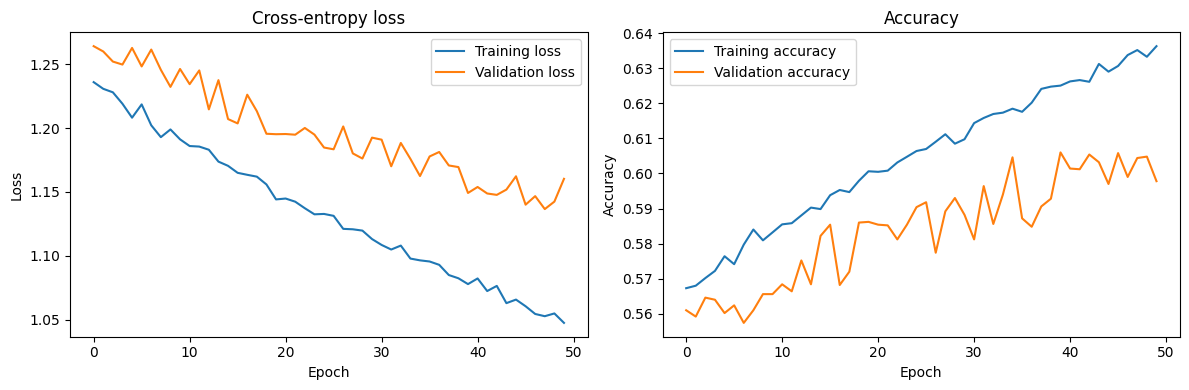

In [33]:
# Your code here :


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"], label="Training loss")
axes[0].plot(history.history["val_loss"], label="Validation loss")
axes[0].set_title("Cross-entropy loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="Training accuracy")
axes[1].plot(history.history["val_accuracy"], label="Validation accuracy")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

## Defining Deeper Architectures: VGG Models

*   Define a deeper model architecture for CIFAR-10 dataset and train the new model for 50 epochs with a batch size of 512. We will use VGG model as the architecture.

Stack two convolutional layers with 32 filters, each of 3 x 3. 

Use a max pooling layer and next flatten the output of the previous layer and add a dense layer with 128 units before the classification layer. 

For all the layers, use ReLU activation function. 

Use same padding for the layers to ensure that the height and width of each layer output matches the input


In [34]:
from keras.backend import clear_session
clear_session()

In [35]:
# Your code here :
model = keras.Sequential(
    [
        keras.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),  
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 814,378 (3.11 MB)

 Trainable params: 814,378 (3.11 MB)

 Non-trainable params: 0 (0.00 B)

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 50 epochs with a batch size of 512.

In [36]:
# Your code here :
batch_size = 512
epochs = 50

model.compile(loss="categorical_crossentropy", optimizer="SGD", metrics=["accuracy"])

history = model.fit(x_train_norm, y_train_cat, batch_size=batch_size, epochs=epochs, validation_split=0.1)

"""
## Evaluate the trained model
"""

score = model.evaluate(x_test_norm, y_test_cat, verbose=2)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - accuracy: 0.1870 - loss: 2.2408 - val_accuracy: 0.2382 - val_loss: 2.1638
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.2653 - loss: 2.0836 - val_accuracy: 0.2624 - val_loss: 2.0733
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.2946 - loss: 1.9946 - val_accuracy: 0.3072 - val_loss: 1.9453
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.3113 - loss: 1.9472 - val_accuracy: 0.3156 - val_loss: 1.9556
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.3372 - loss: 1.8920 - val_accuracy: 0.3346 - val_loss: 1.8816
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.3530 - loss: 1.8488 - val_accuracy: 0.3352 - val_loss: 1.8731
Epoch 7/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.3638 - loss: 1.8229 - val_accuracy: 0.3610 - val_loss: 1.8379
Epoch 8/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.3744 - loss: 1.7891 - val_accuracy: 0.3796 - v

*   Compare the performance of both the models by plotting the loss and accuracy curves of both the training steps. Does the deeper model perform better? Comment on the observation.
 

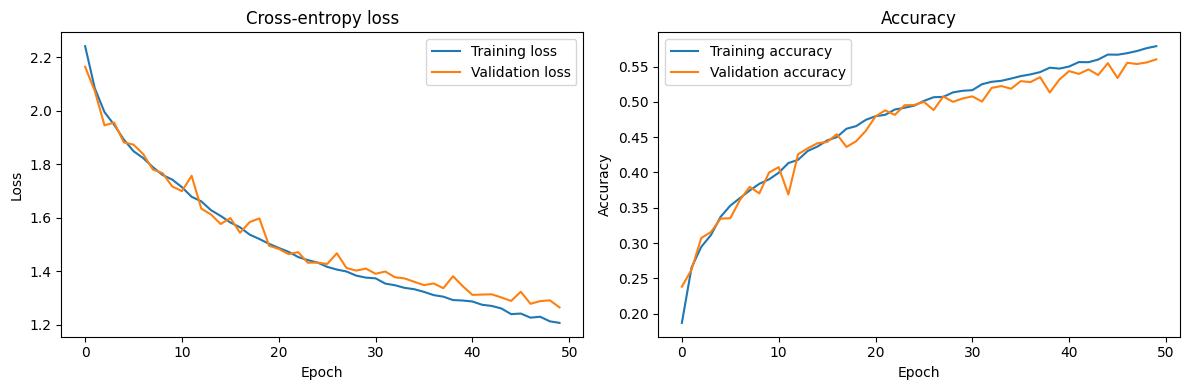

In [37]:
# Your code here :
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"], label="Training loss")
axes[0].plot(history.history["val_loss"], label="Validation loss")
axes[0].set_title("Cross-entropy loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="Training accuracy")
axes[1].plot(history.history["val_accuracy"], label="Validation accuracy")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

**Comment on the observation**
the difference is subtel


...

*   Use predict function to predict the output for the test split
*   Plot the confusion matrix for the new model and comment on the class confusions.


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


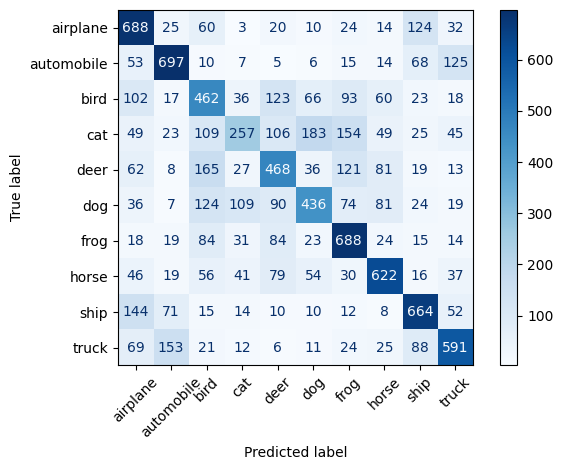

In [40]:
# Your code here :
y_pred_prob = model.predict(x_test_norm)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = y_test.reshape(-1)

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
cm = confusion_matrix(y_true, y_pred, labels=np.arange(10))

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
display.plot(cmap="Blues", xticks_rotation=45, values_format="d")
plt.tight_layout()
plt.show()

**Comment here :**

*(Double-click or enter to edit)*

...

*    Print the test accuracy for the trained model.

In [41]:
# Your code here :
print("Test accuracy:", score[1])

Test accuracy: 0.5572999715805054


## Define the complete VGG architecture.

Stack two convolutional layers with 64 filters, each of 3 x 3 followed by max pooling layer. 

Stack two more convolutional layers with 128 filters, each of 3 x 3, followed by max pooling, followed by two more convolutional layers with 256 filters, each of 3 x 3, followed by max pooling. 

Flatten the output of the previous layer and add a dense layer with 128 units before the classification layer. 

For all the layers, use ReLU activation function. 

Use same padding for the layers to ensure that the height and width of each layer output matches the input

*   Change the size of input to 64 x 64.

In [15]:
from keras.backend import clear_session
clear_session()

In [42]:
import tensorflow as tf

x_train_64 = tf.image.resize(x_train_norm, (64, 64))
x_test_64 = tf.image.resize(x_test_norm, (64, 64))

model = keras.Sequential([
    keras.Input(shape=(64, 64, 3)),

    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), padding="same", activation="relu"),
    layers.Conv2D(256, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,243,978 (12.37 MB)

 Trainable params: 3,243,978 (12.37 MB)

 Non-trainable params: 0 (0.00 B)

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 10 epochs with a batch size of 512.
*   Predict the output for the test split and plot the confusion matrix for the new model and comment on the class confusions.

Epoch 1/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.1206 - loss: 2.3003 - val_accuracy: 0.1470 - val_loss: 2.2977
Epoch 2/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 35s 397ms/step - accuracy: 0.1602 - loss: 2.2937 - val_accuracy: 0.1890 - val_loss: 2.2865
Epoch 3/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 35s 398ms/step - accuracy: 0.1905 - loss: 2.2681 - val_accuracy: 0.1926 - val_loss: 2.2295
Epoch 4/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 35s 398ms/step - accuracy: 0.2344 - loss: 2.1537 - val_accuracy: 0.2828 - val_loss: 2.0436
Epoch 5/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 35s 399ms/step - accuracy: 0.2671 - loss: 2.0410 - val_accuracy: 0.2290 - val_loss: 2.1401
Epoch 6/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 35s 399ms/step - accuracy: 0.2974 - loss: 1.9772 - val_accuracy: 0.2916 - val_loss: 1.9558
Epoch 7/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 35s 398ms/step - accuracy: 0.3252 - loss: 1.9131 - val_accuracy: 0.3244 - val_loss: 1.9035
Epoch 8/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 35s 399ms/step - accuracy: 0.3378 - loss: 1.8626 - val_accura

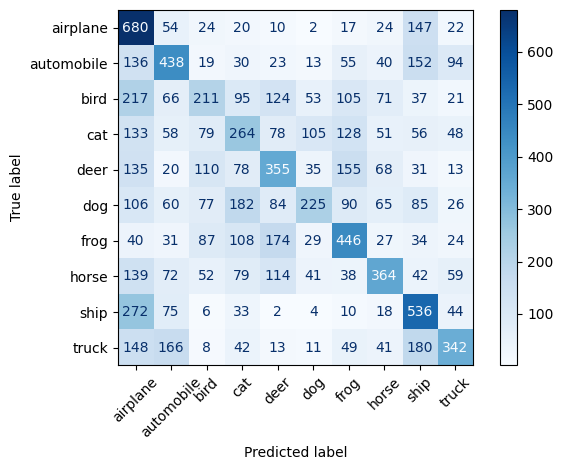

In [43]:
batch_size = 512
epochs = 10

model.compile(
    loss="categorical_crossentropy",
    optimizer="SGD",
    metrics=["accuracy"],
)

history = model.fit(
    x_train_64,
    y_train_cat,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.1,
)

score = model.evaluate(x_test_64, y_test_cat, verbose=2)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

y_pred_prob = model.predict(x_test_64)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = y_test.reshape(-1)

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_true, y_pred, labels=np.arange(10))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names,
).plot(cmap="Blues", xticks_rotation=45, values_format="d")
plt.tight_layout()
plt.show()

# Understanding deep networks

*   What is the use of activation functions in network? Why is it needed?
*   We have used softmax activation function in the exercise. There are other activation functions available too. What is the difference between sigmoid activation and softmax activation?
*   What is the difference between categorical crossentropy and binary crossentropy loss?

**Write the answers below :**

1 - Use of activation functions:

Activation functions add non-linearity to a neural network, allowing it to learn complex patterns. Without non-linear activations, stacking layers would behave like a single linear transformation. ReLU is commonly used in hidden layers; softmax is used in the output layer for this 10-class classification task.

2 - Key Differences between sigmoid and softmax:

Sigmoid maps each output independently to a value between 0 and 1, so it is useful for binary classification or multi-label tasks where more than one class can be true. Softmax converts all class scores into probabilities that sum to 1, making it suitable for mutually exclusive classes such as CIFAR-10, where each image belongs to one class.

3 - Key Differences between categorical crossentropy and binary crossentropy loss:

Categorical crossentropy measures the difference between the predicted class-probability distribution and a one-hot encoded target; it is appropriate for mutually exclusive multi-class classification. Binary crossentropy evaluates binary targets independently and is used for binary classification or multi-label classification. Here, CIFAR-10 has one class per image and the labels are one-hot encoded, so categorical crossentropy is appropriate.